# Superdense Coding Protocol

In [27]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
import numpy as np
from IPython.display import display
from typing import Dict

In [28]:
def run_and_plot_counts(circ, backend, shots=1024, title=None) -> Dict[str, int]:
    """Run a circuit and return counts in |q0 ... qn> order."""

    job = backend.run(circ, shots=shots)
    result = job.result()
    counts = result.get_counts(0)

    counts_left_order = {
        bitstring[::-1]: count
        for bitstring, count in counts.items()
    }

    display(plot_histogram(counts_left_order, title=title))
    return counts_left_order


In [29]:
def get_statevector(circ):
    """Return Statevector reordered to |q0 ... qn> basis."""

    sv = Statevector.from_instruction(circ)
    n = int(np.log2(len(sv)))

    reordered = np.zeros_like(sv.data, dtype=complex)

    for i, amp in enumerate(sv.data):
        b = format(i, f"0{n}b")
        b_rev = b[::-1]
        j = int(b_rev, 2)
        reordered[j] = amp

    return Statevector(reordered)

In [37]:
def superdense_coding(bits):
    qc = QuantumCircuit(2, 2)

    # Create Bell pair
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier()
    sv_bell = get_statevector(qc)
    display(sv_bell.draw('latex', prefix="|bell-state⟩ = "))

    # Alice encodes classical bits
    if bits == "01":
        qc.x(0)
    elif bits == "10":
        qc.z(0)
    elif bits == "11":
        qc.x(0)
        qc.z(0)
    qc.barrier()
    sv_encode = get_statevector(qc)
    display(sv_encode.draw('latex', prefix="|encode⟩ = "))

    # Bob decodes
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()
    sv_decode = get_statevector(qc)
    display(sv_decode.draw('latex', prefix="|decode⟩ = "))

    qc.measure([0,1], [0,1])
    return qc

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

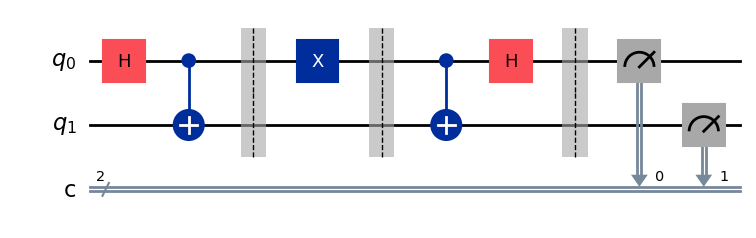

In [38]:
qc = superdense_coding("01")
qc.draw('mpl')

In [32]:
ideal_sim = AerSimulator()
noisy_sim = FakeSherbrooke()

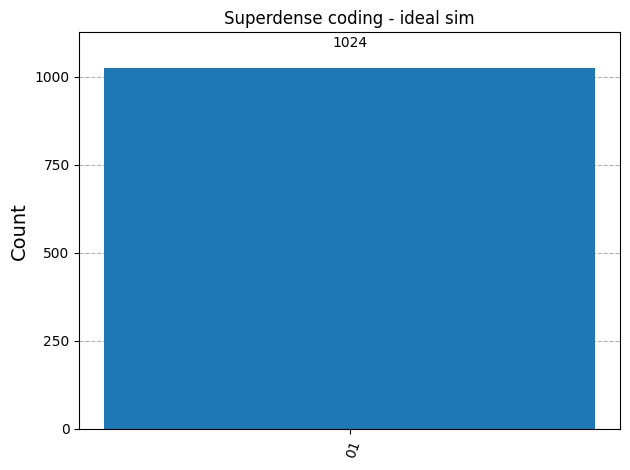

{'01': 1024}

In [33]:
run_and_plot_counts(qc, ideal_sim, shots=1024, title="Superdense coding - ideal sim")

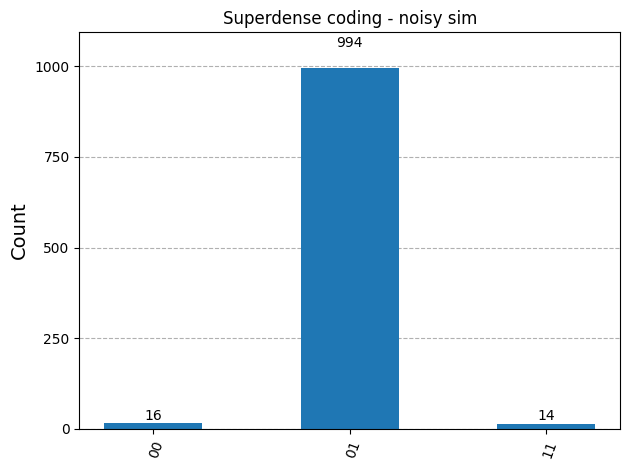

{'11': 14, '00': 16, '01': 994}

In [36]:
run_and_plot_counts(qc, noisy_sim, shots=1024, title="Superdense coding - noisy sim")